In [22]:
# Exercise 1: Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.impute import SimpleImputer



In [23]:

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)


df = df.dropna()

df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
6049,2009-01-01,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,...,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,No
6050,2009-01-02,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,...,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,No
6052,2009-01-04,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,...,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,No
6053,2009-01-05,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,...,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,No
6054,2009-01-06,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,...,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No,No


In [24]:

df = df[df['Location'] == 'Melbourne']


def map_season(date_str):
    month = pd.to_datetime(date_str).month
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df['Season'] = df['Date'].apply(map_season)


df = df.drop(columns=['Date', 'Location'])
df.head()


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Season
67200,9.5,15.4,2.0,2.8,7.0,W,63.0,W,W,37.0,...,38.0,1006.8,1010.3,1.0,7.0,11.0,14.6,Yes,No,Winter
67201,11.0,14.5,0.6,5.2,4.0,W,63.0,W,WSW,30.0,...,52.0,1013.4,1016.2,7.0,4.0,11.8,13.7,No,Yes,Winter
67202,8.4,14.1,1.4,2.0,0.8,W,39.0,W,W,17.0,...,58.0,1024.8,1024.3,7.0,7.0,10.6,13.9,Yes,No,Winter
67203,9.1,14.5,0.6,1.8,4.2,E,19.0,NNW,N,9.0,...,49.0,1030.2,1029.0,7.0,6.0,10.2,13.1,No,No,Winter
67204,4.3,15.5,0.0,0.8,8.4,N,52.0,N,NNE,24.0,...,52.0,1028.9,1024.9,2.0,5.0,5.5,14.6,No,No,Winter


In [25]:
# Exercise 2
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow'].map({'Yes': 1, 'No': 0})


In [26]:
# Exercise 3
print(y.value_counts())

# Markdown conclusion
# - It rains on ~22% of days in Melbourne.
# - A naive model predicting "No rain every day" would be ~78% accurate.
# - This is an imbalanced dataset, so accuracy is misleading.


RainTomorrow
0    1427
1     471
Name: count, dtype: int64


In [ ]:
# Correct version using 1 = Rain
rain_days = class_counts[1]   # "RainTomorrow = 1"
total_days = class_counts.sum()
rain_percentage = rain_days / total_days * 100
print(f"\nIt rains on about {rain_percentage:.2f}% of the days in Melbourne.")

# Always predicting 'No rain'
always_no_accuracy = class_counts[0] / total_days * 100
print(f"If we always predict 'No rain', accuracy would be: {always_no_accuracy:.2f}%")

# Check if dataset is balanced
imbalance_ratio = abs(class_counts[0] - class_counts[1]) / total_days
if imbalance_ratio > 0.2:
    print("\n The dataset is imbalanced.")
else:
    print("\n The dataset is balanced.")



It rains on about 24.82% of the days in Melbourne.
If we always predict 'No rain', accuracy would be: 75.18%

⚠️ The dataset is imbalanced.


In [30]:
# Exercise 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
# Exercise 6
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)


In [ ]:

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric features:", numeric_features.tolist())
print("Categorical features:", categorical_features.tolist())

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a single preprocessing transformer (Exercise 7)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocessing transformer created successfully!")

Numeric features: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical features: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season']
✅ Preprocessing transformer created successfully!


In [33]:
# Exercise 8
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None]
}


In [34]:
# Exercise 9
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 200}
Best CV Score: 0.5510385716756903


Test Score: 0.5
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       286
           1       0.69      0.39      0.50        94

    accuracy                           0.81       380
   macro avg       0.76      0.67      0.69       380
weighted avg       0.79      0.81      0.79       380



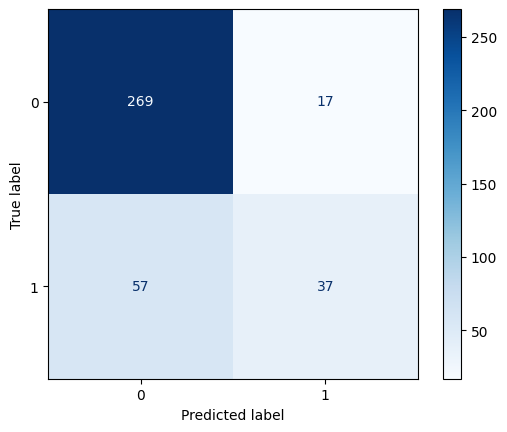

In [35]:
# Exercise 10
print("Test Score:", grid_search.score(X_test, y_test))

# Exercise 11
y_pred = grid_search.predict(X_test)

# Exercise 12
print(classification_report(y_test, y_pred))

# Exercise 13
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()


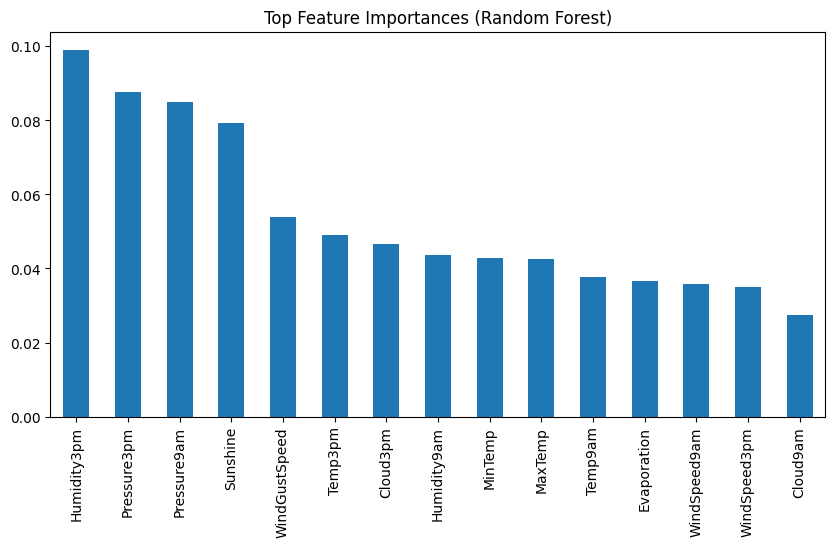

In [36]:
# Exercise 14
best_rf = grid_search.best_estimator_.named_steps['classifier']
ohe = grid_search.best_estimator_.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_names = ohe.get_feature_names_out(cat_features)

feature_names = np.concatenate([num_features, cat_names])
importances = best_rf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Feature Importances (Random Forest)")
plt.show()


Best Params (LR): {'classifier__C': 0.1, 'classifier__penalty': 'l2'}
Best CV Score (LR): 0.5817965418155484
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       286
           1       0.59      0.43      0.49        94

    accuracy                           0.78       380
   macro avg       0.71      0.66      0.68       380
weighted avg       0.77      0.78      0.77       380



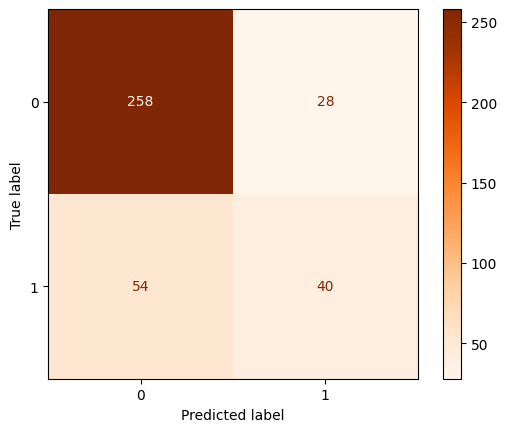

In [37]:
# Exercise 15
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2']
}

grid_search_lr = GridSearchCV(logreg_pipeline, param_grid_lr, cv=cv, scoring='f1', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print("Best Params (LR):", grid_search_lr.best_params_)
print("Best CV Score (LR):", grid_search_lr.best_score_)

# Evaluate
y_pred_lr = grid_search_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Oranges")
plt.show()


In [42]:
# Random Forest
grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Logistic Regression
grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)


NameError: name 'pipeline_rf' is not defined